# Импорты библиотек, seed и устройство

## Импорт библиотек

In [1]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


## Зафиксировал seed и определил устройство

In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


# Данные и DataLoader

## Вспомогательные функции

In [3]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_save_history(history: dict, title: str = "", save_title: str = "test_plot") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"./artifacts/figures/{save_title}.png")
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_save_history_double(history: dict, history2: dict, title: str = "", title2: str = "", save_title: str = "test_plot2") -> None:
    fig, (plt1, plt2) = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs1 = np.arange(1, len(history["train_loss"]) + 1)
    plt1.plot(epochs1, history["train_loss"], label="train_loss")
    plt1.plot(epochs1, history["val_loss"], label="val_loss")
    plt1.set_xlabel("epoch")
    plt1.set_ylabel("loss")
    plt1.set_title((title + " (loss)") if title else "loss")
    plt1.legend()
    plt1.grid(True)

    epochs2 = np.arange(1, len(history2["train_loss"]) + 1)
    plt2.plot(epochs2, history2["train_loss"], label="train_loss")
    plt2.plot(epochs2, history2["val_loss"], label="val_loss")
    plt2.set_xlabel("epoch")
    plt2.set_ylabel("loss")
    plt2.set_title((title2 + " (loss)") if title2 else "loss")
    plt2.legend()
    plt2.grid(True)

    plt.savefig(f"./artifacts/figures/{save_title}.png")

## Работа с данными

Загрузка датасета CIFAR10, определение transform, разбиение на train и test

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
])

train_full = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

D:\aie\aie-student-lnv\homeworks\HW08-09\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train size: 50000
test size: 10000


## DataLoader и батчи

In [5]:
BATCH_SIZE = 256 if device.type == "cuda" else 64

NUM_WORKERS = 0 if os.name == "nt" else 2

val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 3, 32, 32]) torch.float32
y_batch: torch.Size([64]) torch.int64


Видим x_batch.shape и y_batch.shape

# Модель MLP и цикл обучения

## Реализация MLP как nn.Module

In [6]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 32 * 32 * 3,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([64, 10])


## Функция обновления весов и счета метрик на val/test

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

## Ранняя остановка

In [8]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


# Эксперименты

In [9]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

## Часть A

### E1

Базовый MLP для оценки падения loss, роста accuracy и признаков переобучения

epoch 01/20 | train loss=1.6454, acc=0.4176 | val loss=1.5226, acc=0.4604
epoch 02/20 | train loss=1.4440, acc=0.4895 | val loss=1.4436, acc=0.4978
epoch 03/20 | train loss=1.3358, acc=0.5275 | val loss=1.4172, acc=0.4982
epoch 04/20 | train loss=1.2502, acc=0.5588 | val loss=1.3972, acc=0.5032
epoch 05/20 | train loss=1.1772, acc=0.5801 | val loss=1.4075, acc=0.5127
epoch 06/20 | train loss=1.1072, acc=0.6076 | val loss=1.3932, acc=0.5303
epoch 07/20 | train loss=1.0405, acc=0.6314 | val loss=1.3986, acc=0.5263
epoch 08/20 | train loss=0.9833, acc=0.6514 | val loss=1.4377, acc=0.5247
epoch 09/20 | train loss=0.9254, acc=0.6700 | val loss=1.4814, acc=0.5227
epoch 10/20 | train loss=0.8686, acc=0.6909 | val loss=1.5108, acc=0.5206
epoch 11/20 | train loss=0.8061, acc=0.7144 | val loss=1.5573, acc=0.5196
epoch 12/20 | train loss=0.7685, acc=0.7229 | val loss=1.6321, acc=0.5113
epoch 13/20 | train loss=0.7189, acc=0.7435 | val loss=1.6343, acc=0.5178
epoch 14/20 | train loss=0.6733, acc=0

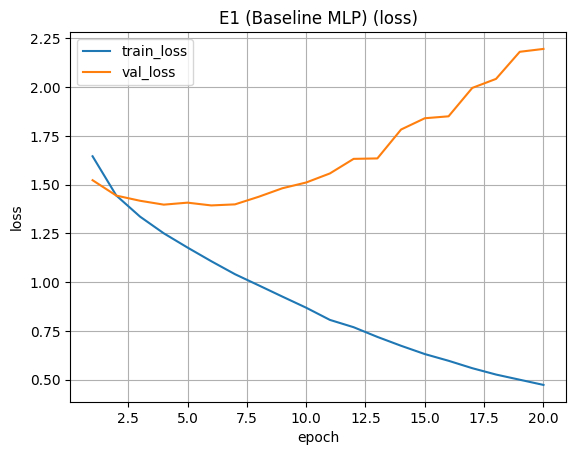

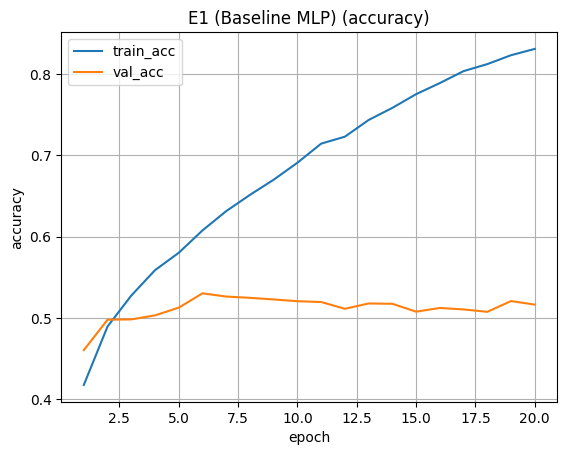

In [10]:
set_seed(42)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="E1 (Baseline MLP)")

### E2

MLP + Dropout

epoch 01/20 | train loss=1.7830, acc=0.3625 | val loss=1.6065, acc=0.4282
epoch 02/20 | train loss=1.6343, acc=0.4206 | val loss=1.5372, acc=0.4678
epoch 03/20 | train loss=1.5716, acc=0.4444 | val loss=1.4866, acc=0.4796
epoch 04/20 | train loss=1.5225, acc=0.4576 | val loss=1.4772, acc=0.4858
epoch 05/20 | train loss=1.4865, acc=0.4744 | val loss=1.4344, acc=0.4927
epoch 06/20 | train loss=1.4612, acc=0.4820 | val loss=1.4125, acc=0.5038
epoch 07/20 | train loss=1.4304, acc=0.4889 | val loss=1.4139, acc=0.5073
epoch 08/20 | train loss=1.4022, acc=0.5025 | val loss=1.3989, acc=0.5081
epoch 09/20 | train loss=1.3838, acc=0.5072 | val loss=1.3783, acc=0.5174
epoch 10/20 | train loss=1.3653, acc=0.5142 | val loss=1.3694, acc=0.5138
epoch 11/20 | train loss=1.3434, acc=0.5231 | val loss=1.3595, acc=0.5176
epoch 12/20 | train loss=1.3236, acc=0.5268 | val loss=1.3443, acc=0.5253
epoch 13/20 | train loss=1.3130, acc=0.5345 | val loss=1.3501, acc=0.5229
epoch 14/20 | train loss=1.2936, acc=0

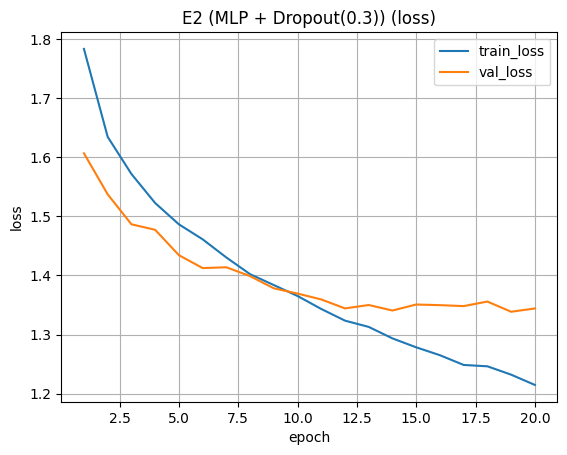

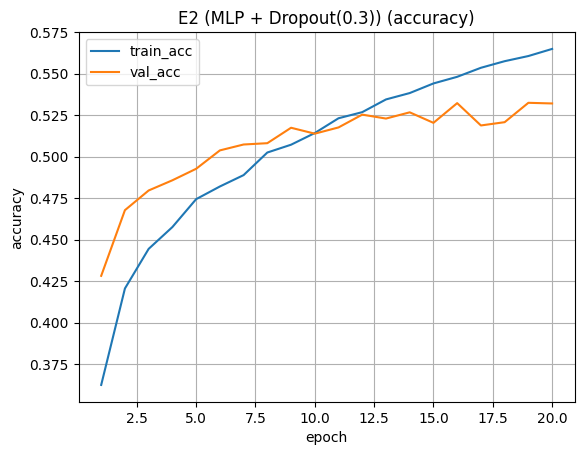

In [11]:
set_seed(42)
dropout_model = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="E2 (MLP + Dropout(0.3))")

### E3

MLP + BatchNorm

epoch 01/20 | train loss=1.6209, acc=0.4220 | val loss=1.4967, acc=0.4583
epoch 02/20 | train loss=1.4206, acc=0.4951 | val loss=1.3984, acc=0.5069
epoch 03/20 | train loss=1.3228, acc=0.5264 | val loss=1.3616, acc=0.5105
epoch 04/20 | train loss=1.2420, acc=0.5575 | val loss=1.3179, acc=0.5263
epoch 05/20 | train loss=1.1739, acc=0.5790 | val loss=1.3417, acc=0.5332
epoch 06/20 | train loss=1.1171, acc=0.6012 | val loss=1.3233, acc=0.5324
epoch 07/20 | train loss=1.0687, acc=0.6184 | val loss=1.3001, acc=0.5494
epoch 08/20 | train loss=1.0121, acc=0.6391 | val loss=1.3148, acc=0.5528
epoch 09/20 | train loss=0.9650, acc=0.6586 | val loss=1.3285, acc=0.5380
epoch 10/20 | train loss=0.9248, acc=0.6716 | val loss=1.3458, acc=0.5425
epoch 11/20 | train loss=0.8845, acc=0.6863 | val loss=1.3562, acc=0.5463
epoch 12/20 | train loss=0.8457, acc=0.6984 | val loss=1.4095, acc=0.5314
epoch 13/20 | train loss=0.8049, acc=0.7154 | val loss=1.4020, acc=0.5427
epoch 14/20 | train loss=0.7681, acc=0

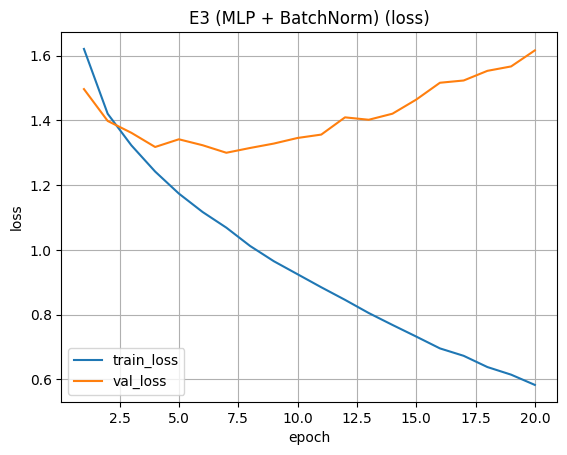

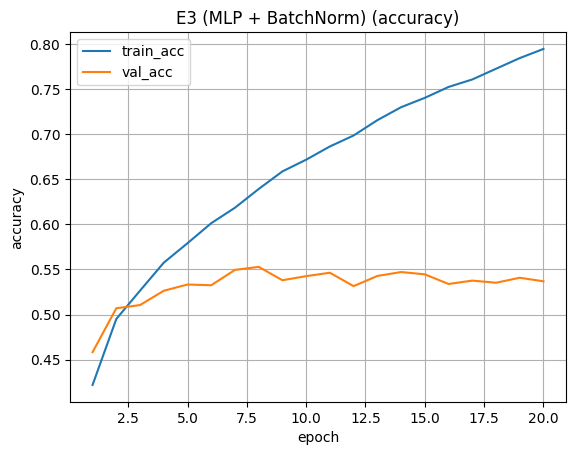

In [12]:
set_seed(42)
bn_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn, title="E3 (MLP + BatchNorm)")

### E4

E4 будем реализовывать с помощью BatchNorm, так как он показал лучший результат по val_accuracy

MLP + BatchNorm + EarlyStopping

epoch 01/50 | train loss=1.6209, acc=0.4220 | val loss=1.4967, acc=0.4583
epoch 02/50 | train loss=1.4206, acc=0.4951 | val loss=1.3984, acc=0.5069
epoch 03/50 | train loss=1.3228, acc=0.5264 | val loss=1.3616, acc=0.5105
epoch 04/50 | train loss=1.2420, acc=0.5575 | val loss=1.3179, acc=0.5263
epoch 05/50 | train loss=1.1739, acc=0.5790 | val loss=1.3417, acc=0.5332
epoch 06/50 | train loss=1.1171, acc=0.6012 | val loss=1.3233, acc=0.5324
epoch 07/50 | train loss=1.0687, acc=0.6184 | val loss=1.3001, acc=0.5494
epoch 08/50 | train loss=1.0121, acc=0.6391 | val loss=1.3148, acc=0.5528
epoch 09/50 | train loss=0.9650, acc=0.6586 | val loss=1.3285, acc=0.5380
epoch 10/50 | train loss=0.9248, acc=0.6716 | val loss=1.3458, acc=0.5425
epoch 11/50 | train loss=0.8845, acc=0.6863 | val loss=1.3562, acc=0.5463
epoch 12/50 | train loss=0.8457, acc=0.6984 | val loss=1.4095, acc=0.5314
EarlyStopping: остановка на эпохе 12. Лучший val_acc=0.5528


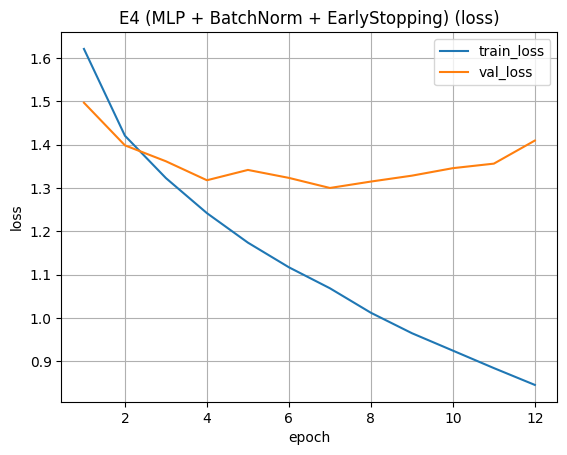

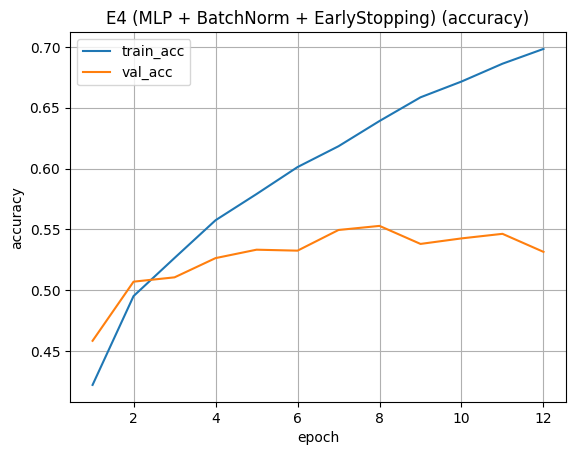

In [23]:
set_seed(42)
combo_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,
    early_stopping=es,
    verbose=True
)

title_e4 = "curves_best"
plot_save_history(history_combo, title="E4 (MLP + BatchNorm + EarlyStopping)", save_title=title_e4)

График train/val loss для лучшего прогона E4 сохранен в файл curves_best.png в папке artifacts/figures

### Сравнение результатов

In [14]:
results = {
    "baseline": evaluate(baseline, test_loader, nn.CrossEntropyLoss(), device)[1],
    "dropout": evaluate(dropout_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "batchnorm": evaluate(bn_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "combo": evaluate(combo_model, test_loader, nn.CrossEntropyLoss(), device)[1],
}

for k, v in results.items():
    print(f"{k:>9}: test_acc={v:.4f}")

 baseline: test_acc=0.5155
  dropout: test_acc=0.5277
batchnorm: test_acc=0.5398
    combo: test_acc=0.5415


Лучший результат у Combo по test_accuracy

## Часть B

### O1

LR слишком большой

epoch 01/8 | train loss=1.8513, acc=0.3319 | val loss=1.7324, acc=0.3770
epoch 02/8 | train loss=1.6774, acc=0.3956 | val loss=1.5994, acc=0.4326
epoch 03/8 | train loss=1.5986, acc=0.4254 | val loss=1.5671, acc=0.4310
epoch 04/8 | train loss=1.5455, acc=0.4452 | val loss=1.5025, acc=0.4701
epoch 05/8 | train loss=1.5047, acc=0.4600 | val loss=1.5389, acc=0.4440
epoch 06/8 | train loss=1.4764, acc=0.4691 | val loss=1.4980, acc=0.4719
epoch 07/8 | train loss=1.4543, acc=0.4825 | val loss=1.4906, acc=0.4790
epoch 08/8 | train loss=1.4243, acc=0.4917 | val loss=1.4958, acc=0.4804


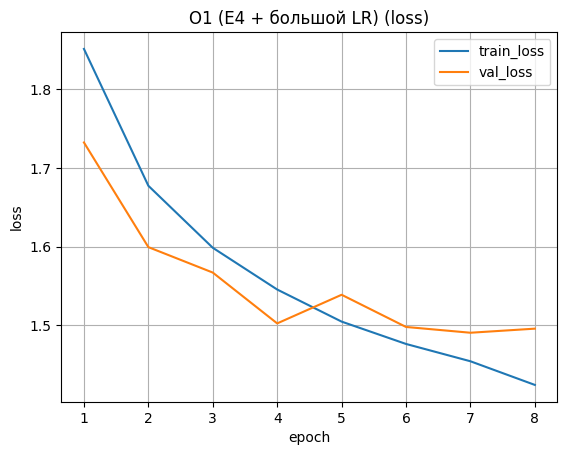

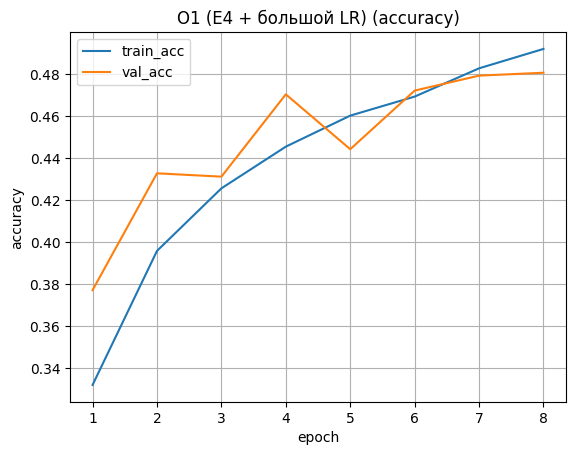

In [15]:
set_seed(42)
o1_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(o1_model.parameters(), lr=1e-1)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_o1 = fit(
    o1_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=8,
    early_stopping=es,
    verbose=True
)

plot_history(history_o1, title="O1 (E4 + большой LR)")

Видим плохой результат

### O2

LR слишком маленький

epoch 01/8 | train loss=1.9706, acc=0.3212 | val loss=1.8248, acc=0.3918
epoch 02/8 | train loss=1.7692, acc=0.4093 | val loss=1.7328, acc=0.4270
epoch 03/8 | train loss=1.6838, acc=0.4383 | val loss=1.6671, acc=0.4482
epoch 04/8 | train loss=1.6230, acc=0.4584 | val loss=1.6200, acc=0.4604
epoch 05/8 | train loss=1.5734, acc=0.4742 | val loss=1.5847, acc=0.4688
epoch 06/8 | train loss=1.5335, acc=0.4869 | val loss=1.5587, acc=0.4786
epoch 07/8 | train loss=1.4968, acc=0.5000 | val loss=1.5304, acc=0.4856
epoch 08/8 | train loss=1.4627, acc=0.5122 | val loss=1.5031, acc=0.4877


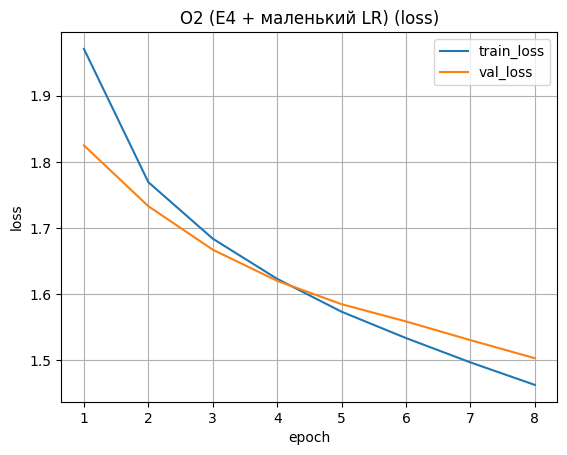

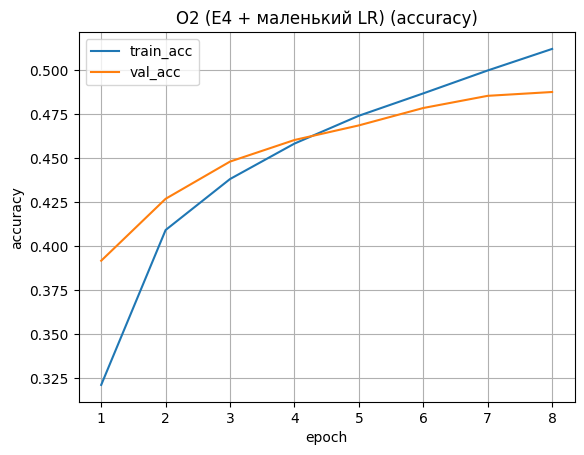

In [16]:
set_seed(42)
o2_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(o2_model.parameters(), lr=1e-5)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_o2 = fit(
    o2_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=8,
    early_stopping=es,
    verbose=True
)

plot_history(history_o2, title="O2 (E4 + маленький LR)")

Обучение происходит очень медленно

### O3

E4 + SGD + momentum + weight_decay

epoch 01/15 | train loss=1.7188, acc=0.4008 | val loss=1.5614, acc=0.4557
epoch 02/15 | train loss=1.4824, acc=0.4786 | val loss=1.4598, acc=0.4929
epoch 03/15 | train loss=1.3767, acc=0.5156 | val loss=1.4046, acc=0.5067
epoch 04/15 | train loss=1.2978, acc=0.5458 | val loss=1.3572, acc=0.5142
epoch 05/15 | train loss=1.2393, acc=0.5667 | val loss=1.3503, acc=0.5222
epoch 06/15 | train loss=1.1873, acc=0.5817 | val loss=1.3507, acc=0.5237
epoch 07/15 | train loss=1.1408, acc=0.6007 | val loss=1.3323, acc=0.5354
epoch 08/15 | train loss=1.0947, acc=0.6169 | val loss=1.3312, acc=0.5344
epoch 09/15 | train loss=1.0558, acc=0.6328 | val loss=1.3581, acc=0.5190
epoch 10/15 | train loss=1.0188, acc=0.6438 | val loss=1.3549, acc=0.5352
epoch 11/15 | train loss=0.9894, acc=0.6545 | val loss=1.3439, acc=0.5352
EarlyStopping: остановка на эпохе 11. Лучший val_acc=0.5354


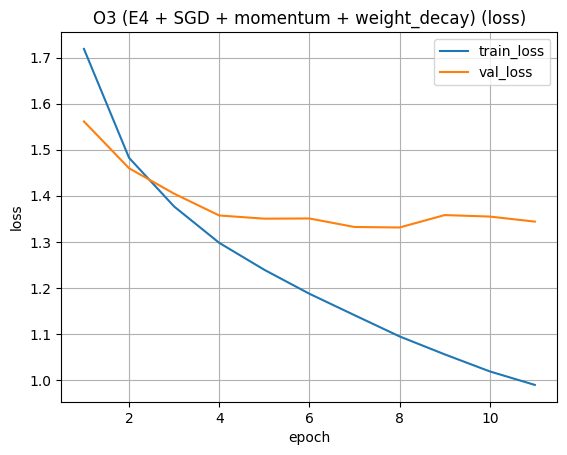

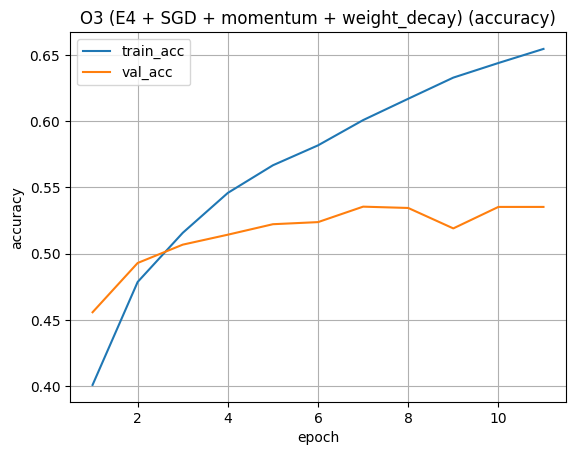

In [17]:
set_seed(42)
o3_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(o3_model.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_o3 = fit(
    o3_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=15,
    early_stopping=es,
    verbose=True
)

plot_history(history_o3, title="O3 (E4 + SGD + momentum + weight_decay)")

# Сохранение артефактов

## Таблица результатов по экспериментам

In [18]:
results = [
    {
        'experiment_id': 'E1',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / False',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 20,
        'best_val_accuracy': 0.5303,
        'best_val_loss': 1.3932
    },
    {
        'experiment_id': 'E2',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.3 / False',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 20,
        'best_val_accuracy': 0.5324,
        'best_val_loss': 1.3387
    },
    {
        'experiment_id': 'E3',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 20,
        'best_val_accuracy': 0.5528,
        'best_val_loss': 1.3148
    },
    {
        'experiment_id': 'E4',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 12,
        'best_val_accuracy': 0.5528,
        'best_val_loss': 1.3148
    },
    {
        'experiment_id': 'O1',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'Adam',
        'lr': 1e-1,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 8,
        'best_val_accuracy': 0.4804,
        'best_val_loss': 1.4958
    },
    {
        'experiment_id': 'O2',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'Adam',
        'lr': 1e-5,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 8,
        'best_val_accuracy': 0.4877,
        'best_val_loss': 1.5031
    },
    {
        'experiment_id': 'O3',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'SGD',
        'lr': 1e-3,
        'momentum': 0.9,
        'weight_decay': 1e-4,
        'epochs_trained': 11,
        'best_val_accuracy': 0.5354,
        'best_val_loss': 1.3323
    },
]

df_runs = pd.DataFrame(results)

output_path = './artifacts/runs.csv'

df_runs.to_csv(output_path, index=False, encoding='utf-8')

## Конфиг лучшей модели

In [22]:
def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


ARTIFACTS_DIR = Path("artifacts")

best_config = {
    "experiment_id": "E4",
    "dataset": "CIFAR10",
    "seed": 42,
    "hidden_sizes": [256, 128],
    "activation": "ReLU",
    "dropout": 0.0,
    "batchnorm": True,
    "optimizer": "Adam",
    "lr": 0.001,
    "batch_size": 64,
    "epochs": 12,
    "momentum": 0,
    "weight_decay": 0,
    "best_val_accuracy": 0.5528,
    "best_val_loss": 1.3148
}

save_json(best_config, ARTIFACTS_DIR / "best_config.json")

## Сохранение графиков O1 и O2

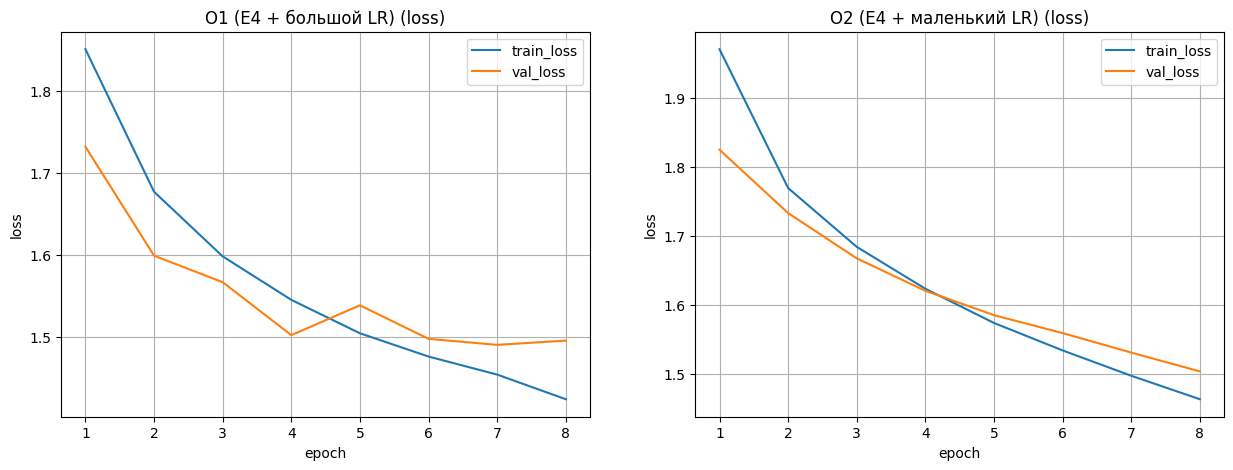

In [24]:
title_lr_experiment = "curves_lr_extremes"
plot_save_history_double(history_o1, history_o2, title="O1 (E4 + большой LR)", title2="O2 (E4 + маленький LR)", save_title=title_lr_experiment)

Графики, показывающие поведение O1 и O2 (LR слишком большой/маленький) сохранены в файл curves_lr_extremes.png в папке artifacts/figures

## Сохранение лучшей модели

In [21]:
tmp_path = './artifacts/best_model.pt'
torch.save(combo_model.state_dict(), tmp_path)